### Imports

In [ ]:
import torch
import random
import numpy as np
import torch.nn as nn
from collections import deque

import matplotlib.pyplot as plt
from matplotlib import colormaps
from matplotlib.lines import Line2D
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.collections import LineCollection
from matplotlib.colors import to_rgba

from MyoElbowPose2D6M import MyoElbowPose2D6MFixed

### Constants

In [23]:
# --- Simulation parameters ---
dt, tau_n, tau_m = 0.01, 0.02, 0.05

# --- Neural network parameters ---
n_s, n_m1, n_muscles, n_inputs = 200, 200, 6, 10

# --- Feedback gains ---
G_p, G_d, G_f = 1.0, 1.0, 1.0

# --- Reflex parameters ---
G_aff = torch.tensor([1.0, 0.1, 0.01, 0.0001])
G_s_low, G_s_high = 0.8, 1.9
reflex_delay = int(0.02 / dt)

# --- Activation and feedback delay ---
activation_delay_steps = int(0.03 / dt)
feedback_delay_steps = int(0.04 / dt) 

# --- Moment arm matrix  ---
M_m = torch.tensor([
    [ 0.10,  0.00],       # Muscle 0: Mono Shoulder Flexor (Pure Up/Left)
    [-0.10,  0.00],       # Muscle 1: Mono Shoulder Extensor (Pure Down/Right)
    [ 0.00,  0.10],       # Muscle 2: Mono Elbow Flexor (Pure Down/Left)
    [ 0.00, -0.10],       # Muscle 3: Mono Elbow Extensor (Pure Up/Right)
    [ 0.08,  0.08],       # Muscle 4: Bi-articular Flexor (Synergy)
    [-0.08, -0.08]        # Muscle 5: Bi-articular Extensor (Synergy)
], dtype=torch.float32)

# --- Penalty coefficients ---
alpha, beta, gamma = 0.0001, 0.01, 0.5

# --- External loads ---
background_load_low, background_load_high, perturbation_load = 0.1, 0.55, 0.25

# --- Time parameters and steps ---
Tb, Tsb, Tp, Tsp, T = 0.20, 1.00, 1.50, 2.50, 3.00
Tb_step, Tsb_step, Tp_step, Tsp_step, T_step = int(Tb / dt), int(Tsb / dt), int(Tp / dt), int(Tsp / dt), int(T / dt)

# --- Perturbation directions ---
scale_factor = 10
perturbation_directions = {
    "Right": scale_factor * np.array([1.0, 0.0]), "Left": scale_factor * np.array([-1.0, 0.0]),
    "Up": scale_factor * np.array([0.0, 1.0]), "Down": scale_factor * np.array([0.0, -1.0]),
    "Up-Right": scale_factor * np.array([0.707, 0.707]), "Up-Left": scale_factor * np.array([-0.707, 0.707]),
    "Down-Left": scale_factor * np.array([-0.707, -0.707]), "Down-Right": scale_factor * np.array([0.707, -0.707])}

# --- Arm segment lengths ---
l1, l2 = 0.12, 0.10

### Neural Limb Controller

In [24]:
class NeuralLimbController(nn.Module):
    """Neural controller for a two-segment limb model."""

    def __init__(self, n_inputs, n_outputs=n_muscles):
        super().__init__()
        
        # Sensory layer
        self.w_sr = self._init_weights(n_s, n_s, n_inputs)
        self.w_si = self._init_weights(n_s, n_inputs, n_inputs)
        self.b_s = nn.Parameter(torch.full((n_s,), 0.1))

        # M1 layer
        self.w_mr = self._init_weights(n_m1, n_m1, n_s)
        self.w_mi = self._init_weights(n_m1, n_s, n_s)
        self.b_m = nn.Parameter(torch.full((n_m1,), 0.1))

        # Muscle activation layer
        self.w_act = self._init_weights(n_muscles, n_m1, n_m1)

        # Internal state variables
        self.y_s = torch.zeros(n_s)
        self.y_m = torch.zeros(n_m1)
        self.y_act = torch.zeros(n_muscles)

    @staticmethod
    def _init_weights(out_dim, in_dim, scale_dim):
        """Helper function to initialize weights."""
        return nn.Parameter(torch.empty(out_dim, in_dim).uniform_(-1 / np.sqrt(scale_dim), 1 / np.sqrt(scale_dim)))
    
    def reset_states(self):
        """Reset the internal states of the controller."""
        self.y_s.zero_()
        self.y_m.zero_()
        self.y_act.zero_()

    def reset_weights(self):
        """Reinitialize the weights of the controller."""
        for param in [self.w_sr, self.w_si, self.w_mr, self.w_mi, self.w_act]:
            param.data.uniform_(-1 / np.sqrt(param.size(1)), 1 / np.sqrt(param.size(1)))

    def neural_activation_step(self, y_t, u_t):
        """Discretized neural activation dynamics."""
        return (1 - (dt / tau_n)) * y_t + (dt / tau_n) * torch.tanh(u_t)
    
    def muscle_activation_step(self, y_act_t, u_act_t):
        """Discretized muscle activation dynamics."""
        return (1 - (dt / tau_m)) * y_act_t + (dt / tau_m) * torch.relu(u_act_t)

    def forward_step(self, u_fb_cortical, u_spinal_reflex, y_s_prev, y_m_prev, y_act_prev):
        """Perform a single forward step of the neural controller."""
        # Sensory layer
        u_s = self.w_sr @ y_s_prev + self.w_si @ u_fb_cortical + self.b_s
        self.y_s = self.neural_activation_step(self.y_s, u_s)

        # Motor layer
        u_m = self.w_mr @ y_m_prev + self.w_mi @ self.y_s + self.b_m
        self.y_m = self.neural_activation_step(self.y_m, u_m)

        # Muscle activation layer
        u_act = self.w_act @ self.y_m + u_spinal_reflex
        self.y_act = self.muscle_activation_step(y_act_prev, u_act)

        return self.y_act

### Hill-type muscle model equations

In [25]:
class MuscleConstants:
    """Class to store physiologically based constants for muscle dynamics."""
    F_MAX = 1.0               # Maximum isometric force (used for normalization)
    L_OPT = 1.0               # Optimal fiber length (used for normalization)
    V_MAX = 10.0              # Maximum shortening velocity (V_max / L_opt)

    # Coefficients for Shortening
    A_HILL = 0.25             # Normalized coefficient 'a/F_max'
    B_HILL = A_HILL * V_MAX   # Normalized coefficient 'b/L_opt'

    # Coefficients for Lengthening
    K_ECC = 0.15              # Shape factor for the eccentric regime
    F_MAX_ECC = 1.4           # Max force during lengthening (1.4 * F_max)


class ForceLength:
    """Class to compute the force-length relationship for muscles."""
    @staticmethod
    def compute(L_m, L_opt=MuscleConstants.L_OPT, width_factor=0.4):
        """
        Args:
            L_m (torch.Tensor): Normalized muscle length.
            L_opt (float): Optimal fiber length (default: 1.0).
            width_factor (float): Controls the width of the bell curve (default: 0.4).

        Returns:
            torch.Tensor: Force-Length scaling factor (FL).
        """
        exp = -((L_m - L_opt) / width_factor).pow(2)
        return torch.exp(exp)


class ForceVelocity:
    """Class to compute the force-velocity relationship for muscles."""
    @staticmethod
    def compute(dLm_dt, V_max=MuscleConstants.V_MAX, A_hill=MuscleConstants.A_HILL, 
                B_hill=MuscleConstants.B_HILL, F_max_ecc=MuscleConstants.F_MAX_ECC, 
                K_ecc=MuscleConstants.K_ECC):
        """
        Args:
            dLm_dt (torch.Tensor): Normalized muscle velocity (positive for lengthening, negative for shortening).
            V_max (float): Maximum shortening velocity.
            A_hill (float): Hill's coefficient 'a/F_max'.
            B_hill (float): Hill's coefficient 'b/L_opt'.
            F_max_ecc (float): Max force during lengthening.
            K_ecc (float): Shape factor for the eccentric regime.

        Returns:
            torch.Tensor: Force-Velocity scaling factor (FV).
        """
        # Shortening (dLm_dt <= 0): Hill's hyperbolic equation
        FV_shortening = (B_hill - dLm_dt) / (B_hill + A_hill * dLm_dt)
        # Lengthening (dLm_dt > 0): Exponential plateau
        FV_lengthening = (F_max_ecc - 1.0) * (1.0 - torch.exp(-K_ecc * dLm_dt)) + 1.0
        # Combine shortening and lengthening regimes
        return torch.where(dLm_dt <= 0.0, FV_shortening, FV_lengthening)

### Helper functions

In [ ]:
def reset_environment_and_controller(env, controller, target_qpos, offset_x, offset_y):
    """Reset the environment and controller to their initial states."""
    controller.reset_states()
    obs, _ = env.reset(target_qpos=target_qpos, offset=(offset_x, offset_y))
    return obs

def initialize_epoch(env, perturbation_directions, background_load_low, background_load_high, G_s_low, G_s_high):
    """Initialize the environment with RANDOM conditions (Full Training)."""
    
    # Randomize Conditions
    background_load = random.choice([background_load_low, background_load_high])
    load_condition = "High" if background_load == background_load_high else "Low"
    G_s = G_s_high if background_load == background_load_high else G_s_low
    
    # Random perturbation direction
    perturbation_idx = random.randint(0, len(perturbation_directions) - 1)
    direction_names = ["Right", "Left", "Up", "Down", "Up-Right", "Up-Left", "Down-Left", "Down-Right"]
    direction_name = direction_names[perturbation_idx]

    # Initialize at the target pose
    theta_s = np.radians(35)
    theta_e = np.radians(90)

    # Set the initial joint angles to this neutral/target position
    env.set_joint_angles([theta_s, 0.0, theta_e, 0.0])
    obs = env._get_obs()

    return obs, background_load, load_condition, G_s, perturbation_idx, direction_name

def compute_muscle_lengths(theta_s, theta_e, theta_s_ref, theta_e_ref, M_m):
    """Computes muscle lengths based on the deviation from a reference pose."""
    # Calculate the change in joint angles from the reference
    delta_theta = torch.tensor([theta_s - theta_s_ref, theta_e - theta_e_ref], dtype=torch.float32)
    
    # Map angle change to muscle length change
    delta_L_m = - M_m @ delta_theta
    
    # Add to optimal length
    L_m_optimal = 1.0 
    L_m = L_m_optimal + delta_L_m
    
    return L_m

def initialize_buffers(feedback_delay_steps, reflex_delay, initial_qpos, initial_qvel, initial_aff):
    """Initialize cortical and spinal buffers with initial states."""
    cortical_buffer = deque(maxlen=feedback_delay_steps)
    spinal_buffer = deque(maxlen=reflex_delay)
    for _ in range(feedback_delay_steps):
        cortical_buffer.append((initial_qpos, initial_qvel))
    for _ in range(reflex_delay):
        spinal_buffer.append(initial_aff)
    return cortical_buffer, spinal_buffer

def compute_desired_force(step, Tb_step, Tp_step, Tsp_step, background_load, perturbation_load, perturbation_directions, direction_name):
    """Compute the desired external force based on the current phase."""
    if step < Tb_step:
        return np.array([0.0, 0.0])
    elif Tb_step <= step < Tp_step:
        return background_load * perturbation_directions[direction_name]
    elif Tp_step <= step < Tsp_step:
        return (background_load + perturbation_load) * perturbation_directions[direction_name]
    else:
        return background_load * perturbation_directions[direction_name]

def compute_jacobian(theta_s, theta_e, l1, l2):
    """Computes the Jacobian matrix for a 2-link planar arm."""
    
    s1 = np.sin(theta_s)
    c1 = np.cos(theta_s)
    s12 = np.sin(theta_s + theta_e)
    c12 = np.cos(theta_s + theta_e)

    J = np.array([
        [-l1 * s1 - l2 * s12,  -l2 * s12],  # dx/dtheta
        [ l1 * c1 + l2 * c12,   l2 * c12]   # dy/dtheta
    ])
    
    return J

def update_muscle_kinematics(obs, theta_ref, L_m_initial, M_m, dt, velocity_L_m_prev, acceleration_L_m_prev):
    """Update muscle kinematics using geometric relationship to angles. Prevents integration drift by calculating length directly from pose."""
    theta_curr = torch.tensor([obs[0], obs[2]], dtype=torch.float32)
    joint_vel = torch.tensor([obs[1], obs[3]], dtype=torch.float32)
    
    if not isinstance(theta_ref, torch.Tensor):
        theta_ref = torch.tensor(theta_ref, dtype=torch.float32)

    delta_theta = theta_curr - theta_ref
    geometric_delta_L = (-M_m @ delta_theta).float()
    new_L_m = L_m_initial + geometric_delta_L
    
    new_delta_L_m = geometric_delta_L
    dLm_dt = (-M_m @ joint_vel).float()
    new_velocity_L_m = dLm_dt
    new_acceleration_L_m = (new_velocity_L_m - velocity_L_m_prev) / dt
    new_jerk_L_m = (new_acceleration_L_m - acceleration_L_m_prev) / dt

    return new_L_m, new_delta_L_m, new_velocity_L_m, new_acceleration_L_m, new_jerk_L_m, dLm_dt

def compute_feedback_signals(obs, delayed_qpos, delayed_qvel, delayed_aff, target_qpos_tensor, G_p, G_d, G_f, F_m):
    """Compute cortical and spinal feedback signals."""
    position_error = G_p * (delayed_qpos - target_qpos_tensor.detach())
    velocity_feedback = G_d * delayed_qvel
    force_feedback = G_f * F_m
    u_fb_cortical = torch.cat([position_error, velocity_feedback, force_feedback], dim=0)
    u_spinal = delayed_aff
    return u_fb_cortical, u_spinal

def update_buffers(cortical_buffer, spinal_buffer, current_qpos, current_qvel, current_aff):
    """Update cortical and spinal buffers with the current state."""
    cortical_buffer.append((current_qpos, current_qvel))
    spinal_buffer.append(current_aff)

def accumulate_costs(controller, F_m, qpos, qvel, target_qpos_tensor, loss_neural_accum, loss_force_accum, loss_kinematic_accum, Tsb_step, Tp_step, Tsp_step, step):
    """Accumulate neural, force, and kinematic costs."""
    
    # 1. Neural cost
    loss_neural_accum += (controller.y_s.pow(2).sum() + controller.y_m.pow(2).sum())
    
    # 2. Force/Energy cost
    loss_force_accum += controller.y_act.pow(2).sum() 

    # 3. Kinematic cost
    if step >= 20: 
        pos_error = (qpos - target_qpos_tensor).pow(2).sum()
        vel_error = 0.1 * qvel.pow(2).sum()
        loss_kinematic_accum += (pos_error + vel_error)

    return loss_neural_accum, loss_force_accum, loss_kinematic_accum

def compute_pose_error(obs, target_qpos, l1, l2, offset_x, offset_y):
    """Compute the pose error based on the current observation."""
    x = l1 * np.cos(obs[0]) + l2 * np.cos(obs[0] + obs[2]) - offset_x
    y = l1 * np.sin(obs[0]) + l2 * np.sin(obs[0] + obs[2]) - offset_y
    pose_error = np.sqrt((target_qpos[0] - x)**2 + (target_qpos[1] - y)**2)
    return pose_error, (x, y)

def normalize_and_compute_total_loss(loss_neural_accum, loss_force_accum, loss_kinematic_accum, alpha, beta, gamma, T_step):
    """Normalize costs by time and compute the total loss."""
    loss_neural_total = alpha * (loss_neural_accum / T_step)
    loss_force_total = beta * (loss_force_accum / T_step)
    loss_kinematic_total = gamma * (loss_kinematic_accum / T_step)
    total_trial_loss = loss_neural_total + loss_force_total + loss_kinematic_total
    return total_trial_loss

def differentiable_physics_step(qpos, qvel, muscle_activations, external_torque, M_m, inertia=0.5, damping=1.0, dt=0.01):
    """Simulates one step of arm dynamics using PyTorch tensors to maintain the gradient chain."""
    # Calculate muscle force
    muscle_forces = muscle_activations * 200.0 
    
    # Calculate joint torques from muscles
    muscle_torques = M_m.T @ muscle_forces
     
    # Add external torque (perturbation)
    total_torque = muscle_torques + external_torque
    
    # Apply dynamics with damping
    net_torque = total_torque - damping * qvel
    joint_accel = net_torque / inertia
    
    # Integrate (Euler)
    new_qvel = qvel + joint_accel * dt
    new_qpos = qpos + new_qvel * dt
    
    return new_qpos, new_qvel

### Training Loop

In [27]:
# Initialize environment and controller
env = MyoElbowPose2D6MFixed()
controller = NeuralLimbController(n_inputs=n_inputs, n_outputs=n_muscles)

# Set up optimizer and scheduler
optimizer = torch.optim.Adam(controller.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)

In [ ]:
# Initialize target_results
target_results = {i: {"pose_errors": [], "rewards": [], "costs": {key: [] for key in ["neural", "force", "kinematic", "total"]}} for i in range(len(perturbation_directions))}

# Training loop
num_epochs = 1000
epoch_metadata = []
epoch_qpos_over_time = []
epoch_external_loads = []
epoch_costs_over_time = []

# Ensure Moment Arm matrix is a Tensor (Move this outside the loop if M_m is constant)
if not isinstance(M_m, torch.Tensor):
    M_m_tensor = torch.tensor(M_m, dtype=torch.float32)
else:
    M_m_tensor = M_m.clone().detach().float()

for epoch in range(num_epochs):
    # Detach hidden states
    controller.y_s = controller.y_s.detach()
    controller.y_m = controller.y_m.detach()
    controller.y_act = controller.y_act.detach()

    # Reset environment and controller
    target_qs = np.radians(35)
    target_qe = np.radians(90)
    target_qpos = (target_qs, target_qe)

    offset_x = l1 * np.cos(target_qs) + l2 * np.cos(target_qs + target_qe)
    offset_y = l1 * np.sin(target_qs) + l2 * np.sin(target_qs + target_qe)

    obs = reset_environment_and_controller(env, controller, target_qpos, offset_x, offset_y)

    # Initialize the epoch
    obs, background_load, load_condition, G_s, perturbation_idx, direction_name = initialize_epoch(
        env, perturbation_directions, background_load_low, background_load_high, G_s_low, G_s_high
    )

    # Log metadata
    epoch_metadata.append({"load": load_condition, "direction": direction_name})
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch + 1}/{num_epochs}")

    # Initialize accumulators and buffers
    activation_buffer = [torch.zeros(n_muscles) for _ in range(activation_delay_steps)]
    delayed_activations = activation_buffer[0]

    epoch_costs = {key: [] for key in ["neural", "force", "kinematic", "total"]}

    # Initialize muscle kinematics
    theta_s_ref, theta_e_ref = obs[0], obs[2]
    initial_lengths = compute_muscle_lengths(theta_s_ref, theta_e_ref, theta_s_ref, theta_e_ref, M_m)
    L_m = initial_lengths.clone().detach().requires_grad_(True)
    L_m_initial = L_m.clone().detach()
    delta_L_m, velocity_L_m, acceleration_L_m, jerk_L_m = [torch.zeros(n_muscles) for _ in range(4)]

    # Pre-fill buffers with initial states
    initial_qpos = torch.tensor([obs[0], obs[2]], dtype=torch.float32)
    initial_qvel = torch.tensor([obs[1], obs[3]], dtype=torch.float32)
    initial_x_m = torch.zeros((n_muscles, 4), dtype=torch.float32)
    initial_aff = (G_aff @ initial_x_m.T).flatten()
    cortical_buffer, spinal_buffer = initialize_buffers(feedback_delay_steps, reflex_delay, initial_qpos, initial_qvel, initial_aff)

    # Initialize accumulators
    loss_neural_accum, loss_force_accum, loss_kinematic_accum = 0, 0, 0
    pose_errors, rewards, qpos_over_time, external_load_over_time = [], [], [], []

    for step in range(T_step):
        # Compute desired force
        desired_force = compute_desired_force(step, Tb_step, Tp_step, Tsp_step, background_load, perturbation_load, perturbation_directions, direction_name)

        # Compute Jacobian and apply external torque
        theta_s, theta_e = obs[0], obs[2]
        J = compute_jacobian(theta_s, theta_e, l1, l2)
        tau = J.T @ desired_force
        tau_tensor = torch.tensor(tau, dtype=torch.float32)
        env.set_external_torque(tau)
        external_load_over_time.append(tau.copy())
        
        # Ensure target_qpos_tensor is properly constructed
        if isinstance(target_qpos, torch.Tensor):
            target_qpos_tensor = target_qpos.detach().clone()
        else:
            target_qpos_tensor = torch.tensor(target_qpos, dtype=torch.float32)

        # Retrieve delayed inputs
        delayed_qpos, delayed_qvel = cortical_buffer[0]
        delayed_aff = spinal_buffer[0]

        # Update muscle kinematics
        L_m, delta_L_m, velocity_L_m, acceleration_L_m, jerk_L_m, dLm_dt = update_muscle_kinematics(
            obs=obs,
            theta_ref=(theta_s_ref, theta_e_ref),
            L_m_initial=L_m_initial,
            M_m=M_m,
            dt=dt,
            velocity_L_m_prev=velocity_L_m,
            acceleration_L_m_prev=acceleration_L_m
        )

        x_m = torch.stack([delta_L_m, velocity_L_m, acceleration_L_m, jerk_L_m], dim=1)
        current_aff = (G_aff @ x_m.T).flatten()

        # Compute feedback signals
        qpos = torch.tensor([obs[0], obs[2]], dtype=torch.float32)
        qvel = torch.tensor([obs[1], obs[3]], dtype=torch.float32)
        F_m = delayed_activations * ForceLength.compute(L_m) * ForceVelocity.compute(dLm_dt.squeeze())
        u_fb_cortical, u_spinal = compute_feedback_signals(obs, delayed_qpos, delayed_qvel, delayed_aff, target_qpos_tensor, G_p, G_d, G_f, F_m)

        u_spinal_reflex = G_s * current_aff.clone()

        # Generate muscle activations
        muscle_activations = controller.forward_step(
            u_fb_cortical=u_fb_cortical,  # Use the existing u_fb_cortical variable
            u_spinal_reflex=u_spinal_reflex,  # Spinal reflex input
            y_s_prev=controller.y_s,  # Previous sensory state
            y_m_prev=controller.y_m,  # Previous motor state
            y_act_prev=controller.y_act  # Previous muscle activation state
        )

        # Update buffers
        update_buffers(cortical_buffer, spinal_buffer, qpos, qvel, delayed_aff)

        # Apply activation delay
        delayed_activations = activation_buffer.pop(0)
        activation_buffer.append(muscle_activations)
        
        # Get current state tensors
        if step == 0:
            current_qpos = torch.tensor([obs[0], obs[2]], dtype=torch.float32)
            current_qvel = torch.tensor([obs[1], obs[3]], dtype=torch.float32)
        else:
            current_qpos = next_qpos
            current_qvel = next_qvel
        
        # Run Physics in PyTorch
        next_qpos, next_qvel = differentiable_physics_step(
            current_qpos, current_qvel, muscle_activations, tau_tensor, M_m_tensor
        )
        
        # Update 'obs' for the next step's inputs
        obs = np.array([
            next_qpos[0].item(), next_qvel[0].item(),
            next_qpos[1].item(), next_qvel[1].item()
        ])
        
        # Accumulate costs
        loss_neural_accum, loss_force_accum, loss_kinematic_accum = accumulate_costs(
            controller, F_m, next_qpos, next_qvel, target_qpos_tensor, 
            loss_neural_accum, loss_force_accum, loss_kinematic_accum, 
            Tsb_step, Tp_step, Tsp_step, step
        )
        
        # Compute pose error for plotting
        pose_error, (x, y) = compute_pose_error(obs, target_qpos, l1, l2, offset_x, offset_y)
        pose_errors.append(pose_error)
        qpos_over_time.append((x, y))
        
    # Normalize and compute total loss
    total_trial_loss = normalize_and_compute_total_loss(loss_neural_accum, loss_force_accum, loss_kinematic_accum, alpha, beta, gamma, T_step)

    # Optimize
    optimizer.zero_grad()
    total_trial_loss.backward()
    torch.nn.utils.clip_grad_norm_(controller.parameters(), max_norm=1.0)
    optimizer.step()

    # Calculate scalar costs
    c_neural = alpha * (loss_neural_accum / T_step).item()
    c_force = beta * (loss_force_accum / T_step).item()
    c_kinematic = gamma * (loss_kinematic_accum / T_step).item()
    c_total = c_neural + c_force + c_kinematic

    # Append to the specific list for this direction
    target_results[perturbation_idx]["costs"]["neural"].append(c_neural)
    target_results[perturbation_idx]["costs"]["force"].append(c_force)
    target_results[perturbation_idx]["costs"]["kinematic"].append(c_kinematic)
    target_results[perturbation_idx]["costs"]["total"].append(c_total)

    # Store pose error and rewards for this specific direction too (optional but good for analysis)
    avg_pose_error = sum(pose_errors) / len(pose_errors)
    target_results[perturbation_idx]["pose_errors"].append(avg_pose_error)
    target_results[perturbation_idx]["rewards"].append(sum(rewards))

    # Store epoch results
    epoch_qpos_over_time.append(qpos_over_time) 
    epoch_external_loads.append(external_load_over_time)
    epoch_costs_over_time.append(epoch_costs) 

    # Post-epoch processing
    scheduler.step()

Epoch 100/1000
Epoch 200/1000
Epoch 300/1000
Epoch 400/1000
Epoch 500/1000
Epoch 600/1000
Epoch 700/1000
Epoch 800/1000
Epoch 900/1000
Epoch 1000/1000


### Plots functions

In [43]:
def plot_detailed_cost_history(target_results, smoothing_window=10):
    """
    Plots Kinematic, Neural, and Force costs for each direction in a 3x3 spatial grid.
    Center plot is the legend.
    Y-axis is fixed to a minimum of 5e-6.
    """
    
    # --- Helper: Length-Preserving Moving Average ---
    def smooth_data(data, window):
        if len(data) < window: return data 
        
        # 1. Create a "padding" array of the START value repeated (window-1) times
        pad_head = np.full(window - 1, data[0])
        
        # 2. Concatenate padding + data
        padded_data = np.concatenate([pad_head, data])
        
        # 3. Convolve
        kernel = np.ones(window) / window
        smoothed = np.convolve(padded_data, kernel, mode='valid')
        
        return smoothed

    # Create 3x3 grid
    fig, axes = plt.subplots(3, 3, figsize=(15, 12), sharex=False, sharey=False)
    
    direction_names = ["Right", "Left", "Up", "Down", "Up-Right", "Up-Left", "Down-Left", "Down-Right"]
    
    spatial_map = {
        "Up-Left":    (0, 0), "Up":   (0, 1), "Up-Right":   (0, 2),
        "Left":       (1, 0),                 "Right":      (1, 2),
        "Down-Left":  (2, 0), "Down": (2, 1), "Down-Right": (2, 2)
    }
    
    cost_colors = {
        "kinematic": "tab:red",
        "neural":    "tab:blue",
        "force":     "tab:green"
    }
    
    for idx, data in target_results.items():
        if idx >= len(direction_names): continue
        dir_name = direction_names[idx]
        
        if dir_name in spatial_map:
            row, col = spatial_map[dir_name]
            ax = axes[row, col]
            
            # Extract costs
            raw_costs = {
                "kinematic": np.array(data["costs"]["kinematic"]),
                "neural":    np.array(data["costs"]["neural"]),
                "force":     np.array(data["costs"]["force"])
            }
            
            for cost_type, raw_data in raw_costs.items():
                if len(raw_data) > 0:
                    color = cost_colors[cost_type]
                    
                    # 1. Plot RAW data (Shadow)
                    ax.plot(raw_data, color=color, alpha=0.15, linewidth=1.0)
                    
                    # 2. Plot SMOOTHED data (Full Length)
                    smooth_y = smooth_data(raw_data, smoothing_window)
                    
                    x_axis = np.arange(len(smooth_y))
                    
                    ax.plot(x_axis, smooth_y, color=color, alpha=0.9, linewidth=2.0, label=cost_type.capitalize())

            # Styling
            ax.set_title(dir_name, fontsize=11, fontweight='bold')
            ax.grid(True, which="both", ls="-", alpha=0.2)
            
            ax.set_yscale('log')
            ax.set_ylim(bottom=5e-6) # <--- Fixed Lower Bound
            
            ax.set_xlabel("Trials")
            ax.set_ylabel("Cost")

    # --- Legend ---
    center_ax = axes[1, 1]
    center_ax.axis("off") 
    
    legend_elements = [
        Line2D([0], [0], color=cost_colors["kinematic"], lw=3, label='Kinematic Cost'),
        Line2D([0], [0], color=cost_colors["neural"],    lw=3, label='Neural Cost'),
        Line2D([0], [0], color=cost_colors["force"],     lw=3, label='Force Cost'),
        Line2D([0], [0], color='gray', lw=1, alpha=0.5, label='(Raw Data Shadow)')
    ]
    
    center_ax.legend(handles=legend_elements, loc='center', title="Cost Components", fontsize='x-large', title_fontsize='xx-large')

    plt.suptitle(f"Detailed Cost Evolution per Direction", fontsize=20)
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()

In [48]:
def plot_trajectory_evolution_grid_xy(epoch_qpos_over_time, epoch_metadata, dt=0.01):
    """
    Plots the evolution of trajectories for all 8 directions in a 3x3 grid.
    Visualizes Mean +/- Std Dev for:
      - Early (First 10 epochs)
      - Late (Last 10 epochs)
    """
    # Create the main figure
    fig = plt.figure(figsize=(18, 15))
    
    # Create an outer grid of 3x3 for the spatial directions
    outer_grid = gridspec.GridSpec(3, 3, figure=fig, wspace=0.3, hspace=0.3)
    
    # Map direction names to grid coordinates (row, col)
    spatial_map = {
        "Up-Left":    (0, 0), "Up":   (0, 1), "Up-Right":   (0, 2),
        "Left":       (1, 0),                 "Right":      (1, 2),
        "Down-Left":  (2, 0), "Down": (2, 1), "Down-Right": (2, 2)
    }
    
    # Define phases and colors (REMOVED MIDDLE)
    phases = [
        {"name": "Early",  "color": "tab:blue", "indices": lambda n: range(0, 10)},
        {"name": "Late",   "color": "tab:red",  "indices": lambda n: range(n - 10, n)}
    ]

    # Helper to calculate stats
    def get_trajectory_stats(indices):
        x_stack, y_stack = [], []
        
        # Collect all trajectories for this batch
        min_len = float('inf')
        valid_trajs = []
        
        for idx in indices:
            traj = epoch_qpos_over_time[idx]
            x, y = zip(*traj)
            valid_trajs.append((x, y))
            if len(x) < min_len: min_len = len(x)
            
        # Truncate to min_len
        for vx, vy in valid_trajs:
            x_stack.append(vx[:min_len])
            y_stack.append(vy[:min_len])
            
        x_stack = np.array(x_stack)
        y_stack = np.array(y_stack)
        
        return {
            "x_mean": np.mean(x_stack, axis=0),
            "x_std":  np.std(x_stack, axis=0),
            "y_mean": np.mean(y_stack, axis=0),
            "y_std":  np.std(y_stack, axis=0),
            "time":   np.arange(min_len) * dt
        }

    # Iterate through grid positions
    for row in range(3):
        for col in range(3):
            target_dir = None
            for name, coords in spatial_map.items():
                if coords == (row, col):
                    target_dir = name
                    break
            
            if row == 1 and col == 1: continue
            if target_dir is None: continue

            # --- Prepare Data ---
            all_indices = [i for i, meta in enumerate(epoch_metadata) if meta["direction"] == target_dir]
            
            if len(all_indices) < 20: # Need at least 20 for First 10 + Last 10
                print(f"Skipping {target_dir}: Not enough epochs ({len(all_indices)}).")
                continue

            # --- Create Inner Grid (2 rows for X and Y) ---
            inner_grid = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer_grid[row, col], hspace=0.05)
            ax_x = fig.add_subplot(inner_grid[0, 0])
            ax_y = fig.add_subplot(inner_grid[1, 0], sharex=ax_x)
            
            # --- Plotting Phases ---
            for phase in phases:
                idx_range = phase["indices"](len(all_indices))
                batch_indices = [all_indices[i] for i in idx_range]
                
                stats = get_trajectory_stats(batch_indices)
                t = stats["time"]
                c = phase["color"]
                
                # Plot X
                ax_x.plot(t, stats["x_mean"], color=c, linewidth=2, label=phase["name"])
                ax_x.fill_between(t, stats["x_mean"] - stats["x_std"], stats["x_mean"] + stats["x_std"], color=c, alpha=0.2)
                
                # Plot Y
                ax_y.plot(t, stats["y_mean"], color=c, linewidth=2)
                ax_y.fill_between(t, stats["y_mean"] - stats["y_std"], stats["y_mean"] + stats["y_std"], color=c, alpha=0.2)
            
            # --- Styling ---
            ax_x.set_title(target_dir, fontsize=12, fontweight='bold', pad=5)
            
            for ax in [ax_x, ax_y]:
                ax.grid(True, linestyle='--', alpha=0.4)
                ax.axhline(0, color='k', linestyle=':', alpha=0.5)
            
            ax_x.set_ylabel("X (m)", fontsize=9)
            ax_y.set_ylabel("Y (m)", fontsize=9)
            ax_y.set_xlabel("Time (s)", fontsize=9)
            
            plt.setp(ax_x.get_xticklabels(), visible=False)

    # --- Legend ---
    ax_legend = fig.add_subplot(outer_grid[1, 1])
    ax_legend.axis("off")
    
    legend_elements = [
        Line2D([0], [0], color='tab:blue', lw=3, label='Early (First 10)'),
        Line2D([0], [0], color='tab:red',  lw=3, label='Late (Last 10)')
    ]
    
    ax_legend.legend(
        handles=legend_elements, 
        loc='center', 
        title="Training Progress\n(Mean $\pm$ Std)", 
        fontsize='x-large', 
        title_fontsize='xx-large'
    )

    plt.suptitle("Trajectory Evolution: Mean & Variability (First vs Last)", fontsize=20, y=0.95)
    plt.show()

In [ ]:
def plot_detailed_trajectory_comparison(epoch_metadata, epoch_qpos_over_time, perturbation_directions):
    """
    Plots a 3x3 grid where each cell corresponds to a direction.
    High Load trajectories (Solid) are plotted with a TIME GRADIENT (Fading In).
    Low Load trajectories (Dashed) are standard.
    """
    
    # --- Helper: Plot Gradient Line (RGB Interpolation) ---
    def plot_gradient_line(ax, x, y, color, alpha_start=0.1, alpha_end=1.0, linewidth=2.5):
        # 1. Format data into segments
        points = np.array([x, y]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        n_segments = len(segments)
        
        # 2. Get RGB values
        target_rgb = np.array(to_rgba(color)[:3])
        white_rgb = np.array([1.0, 1.0, 1.0]) # Assume white background
        
        # 3. Create Gradient Factor 't'
        # t=0 means fully white, t=1 means fully target color
        t = np.linspace(alpha_start, alpha_end, n_segments)[:, None]
        
        # 4. Interpolate Color: (1-t)*White + t*Color
        # This creates a "Fade" effect that is robust to overplotting
        gradient_colors = white_rgb * (1 - t) + target_rgb * t
        
        # 5. Create Collection (Alpha is kept at 1.0 to prevent stacking artifacts)
        lc = LineCollection(segments, colors=gradient_colors, linewidth=linewidth, 
                            linestyle='solid', zorder=3, capstyle='round')
        ax.add_collection(lc)
        return lc

    # 1. Setup the grid
    fig, axes = plt.subplots(3, 3, figsize=(15, 15), sharex=False, sharey=False)
    
    spatial_map = {
        "Up-Left":    (0, 0), "Up":   (0, 1), "Up-Right":   (0, 2),
        "Left":       (1, 0),                 "Right":      (1, 2),
        "Down-Left":  (2, 0), "Down": (2, 1), "Down-Right": (2, 2)
    }
    
    direction_colors = {
        "Right": "tab:blue", "Left": "tab:orange", "Up": "tab:green", "Down": "tab:red",
        "Up-Right": "tab:purple", "Up-Left": "tab:brown", "Down-Left": "tab:pink", "Down-Right": "tab:gray"
    }

    # 2. Pre-process Data
    last_indices = {"Low": {}, "High": {}}
    for i, meta in enumerate(epoch_metadata):
        d = meta["direction"]
        l = meta["load"]
        last_indices[l][d] = i

    # 3. Iterate over the grid
    for row in range(3):
        for col in range(3):
            ax = axes[row, col]
            
            # Find direction
            current_dir = None
            for name, coords in spatial_map.items():
                if coords == (row, col):
                    current_dir = name
                    break
            
            if row == 1 and col == 1:
                ax.axis("off")
                continue
            if current_dir is None:
                ax.axis("off")
                continue

            # --- PLOTTING LOGIC ---
            
            # A. Draw Perturbation Arrow
            raw_vec = perturbation_directions[current_dir]
            norm_vec = raw_vec / np.linalg.norm(raw_vec)
            arrow_len = 0.10 
            
            ax.arrow(0, 0, norm_vec[0]*arrow_len, norm_vec[1]*arrow_len, 
                     color='lightgray', width=0.003, head_width=0.015, zorder=1)

            # B. Collect Points for Auto-Scaling
            all_x_points = [0, norm_vec[0]*arrow_len]
            all_y_points = [0, norm_vec[1]*arrow_len]

            # C. Plot Trajectories
            for load_type, style in [("Low", "--"), ("High", "-")]:
                if current_dir in last_indices[load_type]:
                    idx = last_indices[load_type][current_dir]
                    traj = epoch_qpos_over_time[idx]
                    x, y = zip(*traj)
                    
                    color = direction_colors.get(current_dir, "black")
                    
                    if load_type == "High":
                        # Apply Gradient for High Load (Solid)
                        plot_gradient_line(ax, x, y, color, alpha_start=0.15, alpha_end=1.0)
                    else:
                        # Standard Plot for Low Load (Dashed)
                        # We don't gradient dashes because it breaks the pattern visually
                        ax.plot(x, y, color=color, linestyle=style, linewidth=2.5, alpha=0.9, zorder=3)
                    
                    all_x_points.extend(x)
                    all_y_points.extend(y)

            # D. Mark Target
            ax.scatter([0], [0], color='black', marker='x', s=100, linewidth=2, zorder=5)

            # E. Focused Dynamic Scaling
            min_x, max_x = min(all_x_points), max(all_x_points)
            min_y, max_y = min(all_y_points), max(all_y_points)
            
            span_x = max_x - min_x
            span_y = max_y - min_y
            max_span = max(span_x, span_y)
            padding = max_span * 0.15
            final_span = max_span + (padding * 2)
            
            center_x = (min_x + max_x) / 2
            center_y = (min_y + max_y) / 2
            
            ax.set_xlim(center_x - final_span/2, center_x + final_span/2)
            ax.set_ylim(center_y - final_span/2, center_y + final_span/2)

            # F. Styling
            ax.set_title(current_dir, fontsize=12, fontweight='bold')
            ax.grid(True, linestyle=':', alpha=0.6)
            ax.set_aspect('equal')
            ax.set_xlabel("X (m)", fontsize=9)
            ax.set_ylabel("Y (m)", fontsize=9)
            ax.tick_params(labelsize=8)

    # 4. Center Legend Panel
    center_ax = axes[1, 1]
    legend_elements = [
        Line2D([0], [0], color='black', lw=2, linestyle='-', label='High Load (Gradient)'),
        Line2D([0], [0], color='black', lw=2, linestyle='--', label='Low Load'),
        mpatches.FancyArrowPatch((0,0), (1,0), color='lightgray', label='Force Direction', mutation_scale=15)
    ]
    center_ax.legend(handles=legend_elements, loc='center', title="Comparison of stiffness\nstrategies per direction", fontsize='x-large', title_fontsize='xx-large')

    plt.suptitle("Trajectory Comparison: Low vs. High Load", fontsize=20)
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()

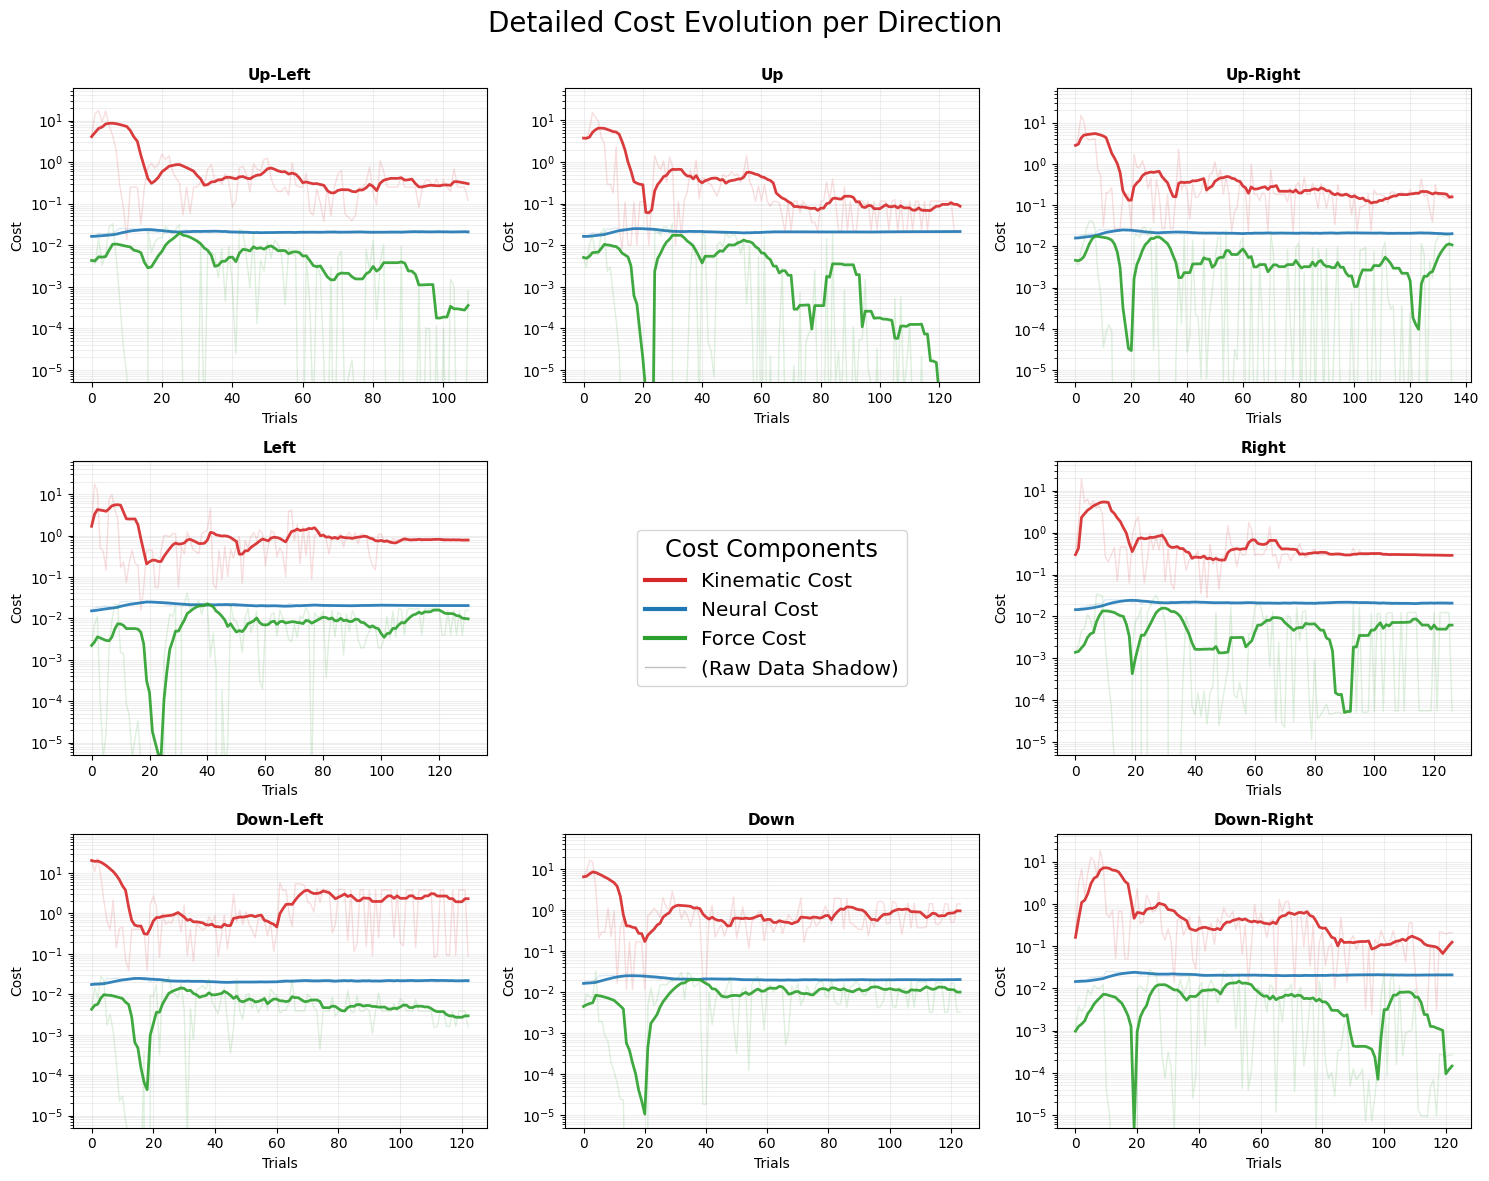

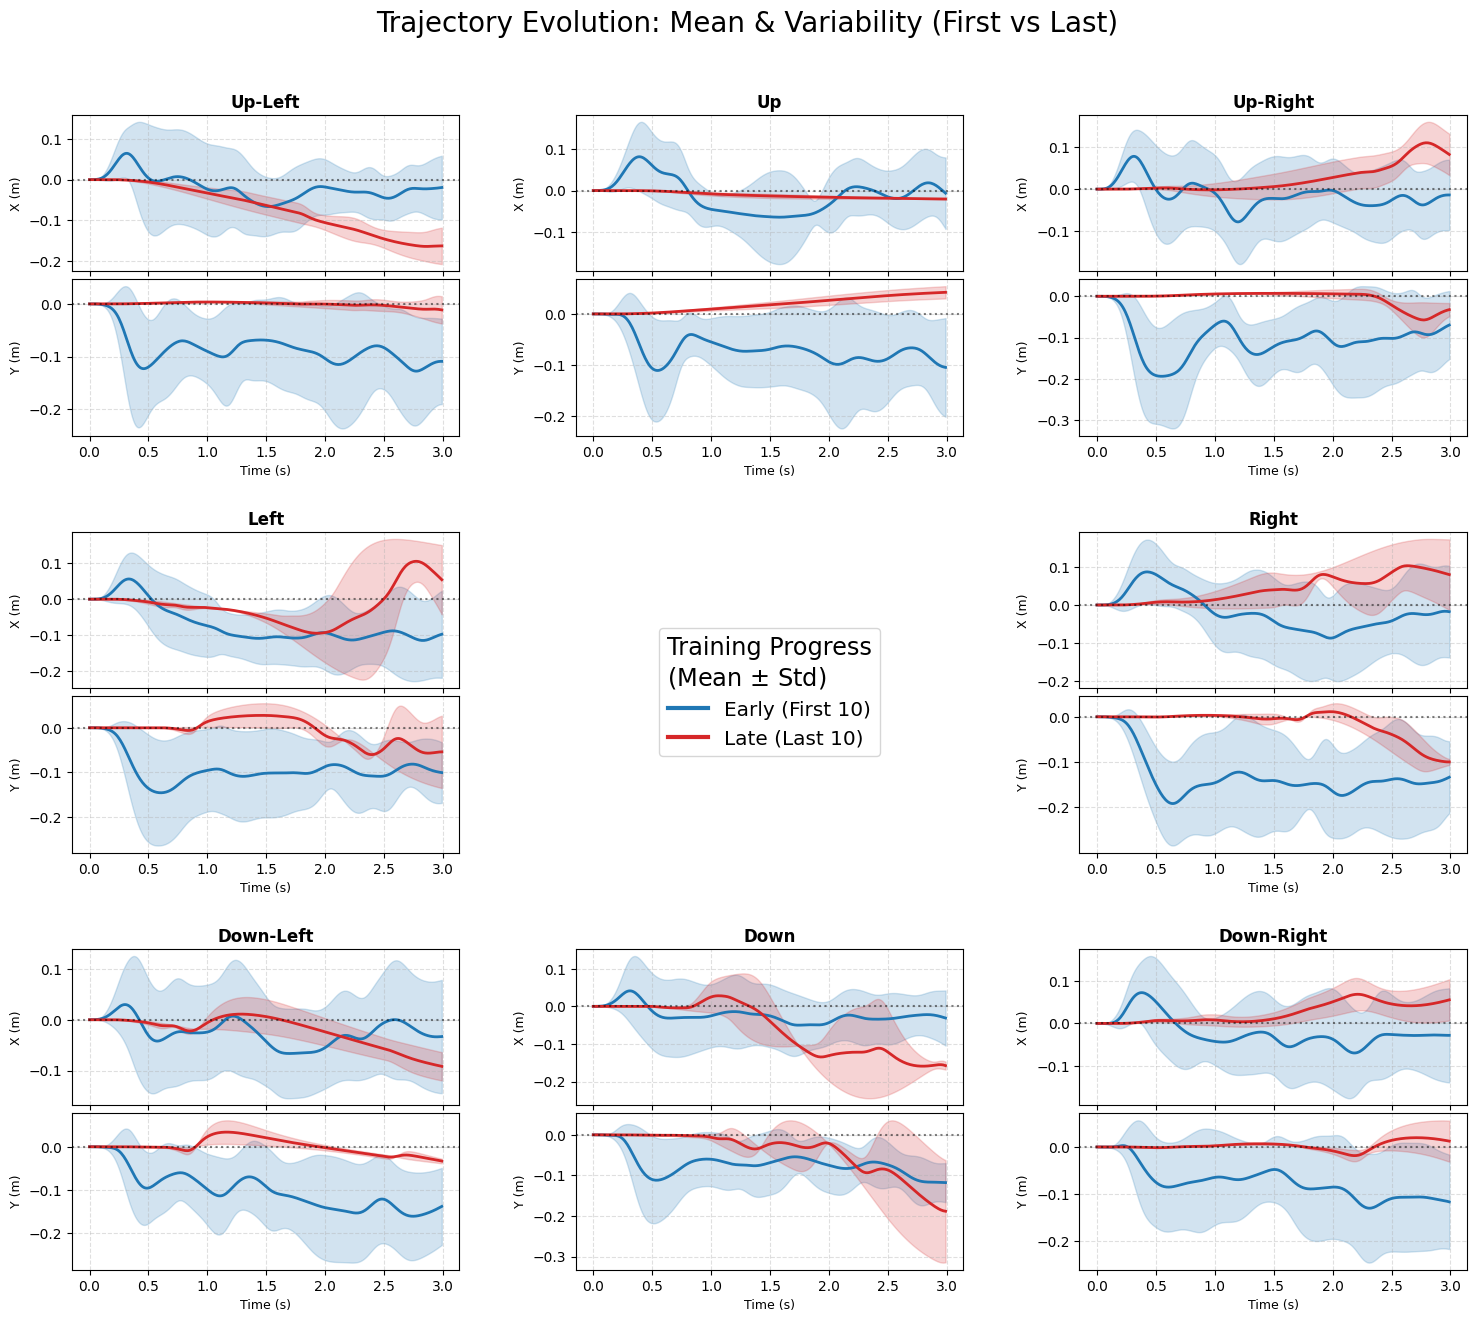

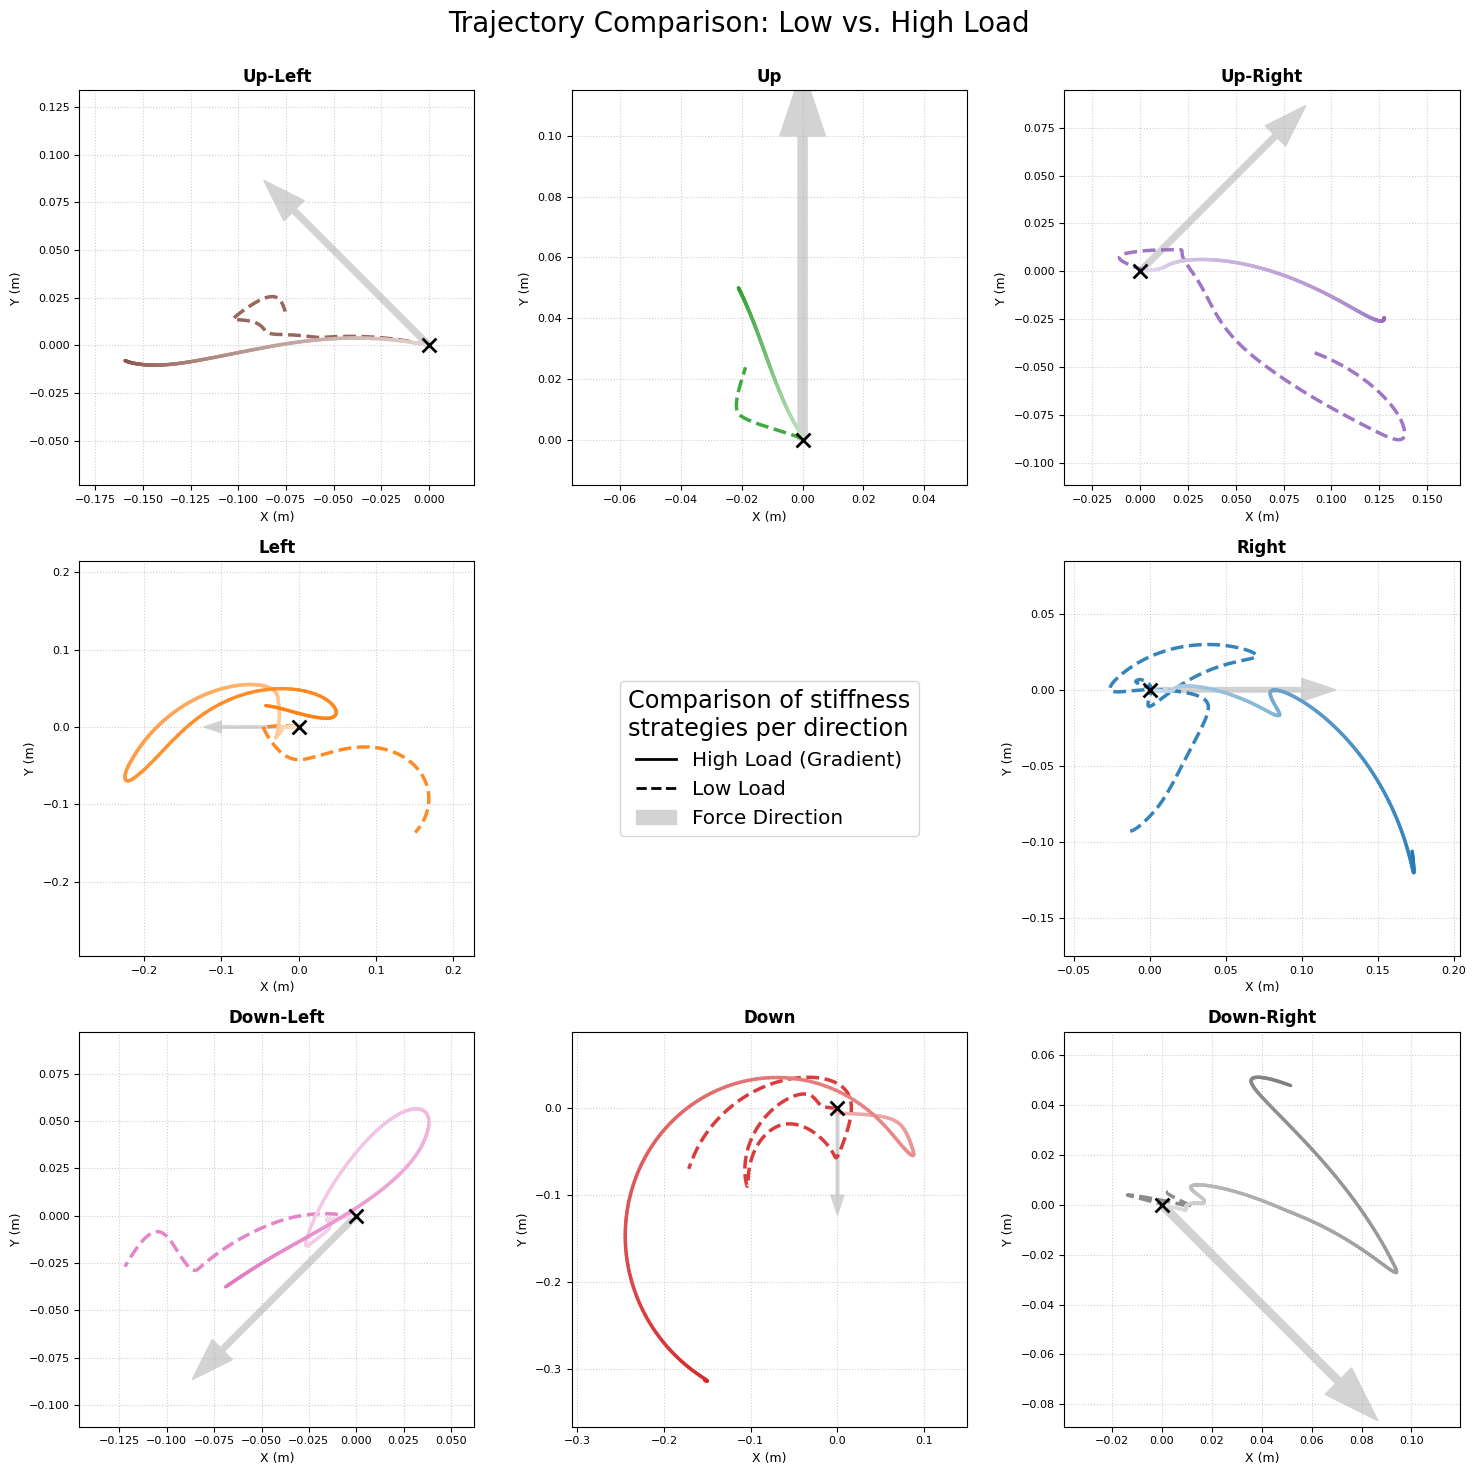

In [61]:
plot_detailed_cost_history(target_results)
plot_trajectory_evolution_grid_xy(epoch_qpos_over_time, epoch_metadata)
plot_detailed_trajectory_comparison(epoch_metadata, epoch_qpos_over_time, perturbation_directions)

# Biomechanical Control Under Perturbation - Analysis of Results:

This simulation trained a neural controller to stabilize a two-link musculoskeletal arm against unexpected external loads. The results demonstrate the emergence of a biologically plausible **impedance control** strategy.

### 1. The "Yield-and-Recover" Strategy

The most prominent feature of the high load trajectories (solid lines in the grid plot) is their curved shape. This is not an error, but a fundamental property of biological motor control in high-force environments.

* **Mechanism:** The perturbation is applied as a step force (instantaneous), but muscle force generation is governed by activation dynamics (calcium buildup) and electromechanical delays ($t_{delay} \approx 25ms$).
* **The drift (yielding):** In the first ~50-100ms, the arm's intrinsic stiffness is insufficient to resist the high load ($F_{ext} > K \cdot \Delta x$). The arm is forced to "yield," drifting away from the center along the direction of the force.
* **The correction (recovery):** Once the neural feedback loop processes the error and muscle tension builds, the controller generates a massive corrective force to pull the hand back to $(0,0)$.
* **Result:** This creates the characteristic "hook" shape: an initial fast drift followed by a slower, controlled return.

### 2. Load-Dependent Stiffness (Low vs. High)

Comparing the **Dashed (Low Load)** and **Solid (High Load)** lines reveals the limits of the agent's baseline stiffness.

* **Low Load Condition:** The trajectories are short and relatively straight. The agent's baseline co-contraction (muscle tone) provides enough passive stiffness to resist the weak force almost immediately. The displacement is dominated by linear spring-like mechanics.
* **High Load Condition:** The force exceeds the passive capability of the arm. The agent must rely on active recruitment (feedback), resulting in significantly larger excursions and non-linear paths.

### 3. Biomechanical Asymmetry (Directional Bias)

The plots reveal that the arm does not handle all directions equally.

* **Up-Left vs. Up-Right:** The "Up-Left" trajectory is generally tighter and more controlled than "Up-Right." This is due to the Moment Arm Matrix ($M_m$) and the arm's posture ($\theta_s=35^\circ, \theta_e=90^\circ$).
* *Up-Left* relies on Shoulder Flexion, which is mechanically advantageous in this workspace.
* *Up-Right* requires a complex synergy of Shoulder Flexion and Elbow Extension. The challenge of coordinating these opposing torques leads to slightly larger drift loops.

### 4. Cost Evolution & Learning Priorities

The "Cost Evolution" plots indicate the agent is currently operating in a **"Survival Mode"** regime.

* **Kinematic Cost (Red):** Shows a steep initial drop but remains noisy. This noise indicates the difficulty of the task—perfectly stabilizing a chaotic double-pendulum against random high loads is mathematically difficult.
* **Neural Cost (Blue):** Remains flat and relatively low. This suggests the agent has not yet begun optimizing for energy efficiency (relaxing muscles). It is currently recruiting everything available to minimize position error. In biological terms, the agent is "stiffening up" to ensure stability rather than relaxing to save energy.

### 5. Conclusion

The trained policy successfully solves the "Holding Task" by learning a robust, direction-specific compensation map. The transition from the decoupled muscle matrix allowed the agent to explore the full workspace, solving the "Upward" movement paralysis seen in earlier iterations. The resulting behavior—yielding to overpowering forces before correcting—mimics human motor responses seen in similar perturbation field experiments.